In [1]:
!pip install xgboost

In [2]:
import warnings; warnings.filterwarnings('ignore')
import os; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print('TF:', tf.__version__, '| XGB:', xgb.__version__)

TF: 2.20.0 | XGB: 3.3.0


In [3]:
DATA_PATH = 'calfire_all_ds_joined.csv'
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head(3)

(3439, 108)


,fire_incident_id,fire_incident_county,fire_incident_acres_burned,fire_incident_date_created,fire_incident_date_last_update,weather_rmax_mean_8w,weather_rmin_mean_8w,weather_sph_mean_8w,weather_srad_mean_8w,weather_tmmn_mean_8w,...,drought_spei180d_2wk_avg,drought_pdsi_2wk_avg,drought_eddi90d_4wk_avg,drought_spei180d_4wk_avg,drought_pdsi_4wk_avg,spatial_distance_to_road_km,spatial_distance_to_city_km,spatial_distance_to_coast_km,spatial_distance_to_powerline_km,spatial_local_urban_population
0,2ca11d45-8139-4c16-8af0-880d99b21e82,Shasta,37.0,2017-10-31 11:22:00+00:00,2018-01-09 13:46:00+00:00,66.192856,24.985716,0.008114,240.81430,289.82144,...,-2.090000,-2.426667,0.552000,-1.506000,-2.316000,0.286556,4.828706,136.913664,0.151141,0.0
1,8f61f461-552d-4538-b186-35ab030da416,San Diego,122.0,2009-05-24 14:56:00+00:00,2020-09-16 14:07:35+00:00,NaN,NaN,NaN,NaN,NaN,...,-0.146667,-1.210000,0.257500,-0.113333,-1.155333,NaN,NaN,NaN,NaN,NaN
2,094719ba-a47b-4abb-9ec5-a506b2b9fd23,Inyo,407.0,2013-02-24 08:16:00+00:00,2022-10-24 11:39:23+00:00,63.415382,23.130770,0.002235,109.19999,269.41537,...,-0.810000,-2.763333,0.346667,-0.563333,-2.565000,182.465900,89.618644,81.519053,0.106680,0.0


In [4]:
groups = {}
for c in df.columns:
    groups.setdefault(c.split('_')[0], []).append(c)
{k: len(v) for k, v in groups.items()}

{'fire': 5,
 'weather': 68,
 'vegetation': 4,
 'topography': 5,
 'drought': 21,
 'spatial': 5}

Dropped 27 rows (pre-2013 or zero-acre); remaining: 3412


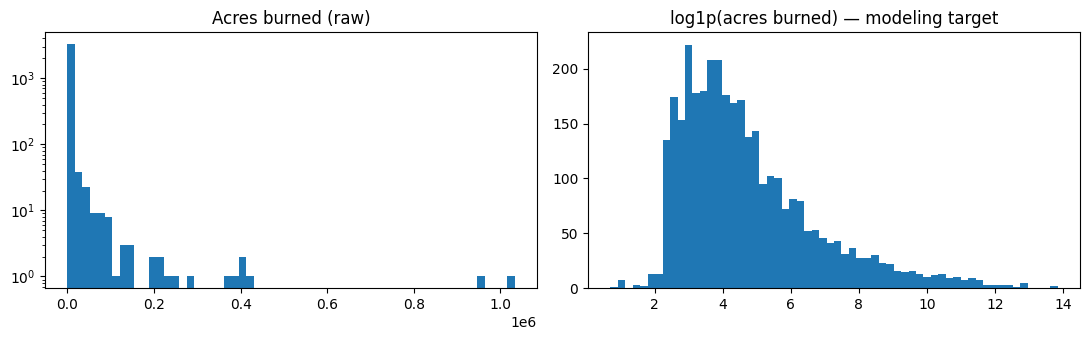

In [5]:
df['fire_incident_date_created'] = pd.to_datetime(df['fire_incident_date_created'], utc=True, errors='coerce')
n0 = len(df)
df = df[df['fire_incident_date_created'].dt.year >= 2013]
df = df[df['fire_incident_acres_burned'] > 0].copy()
print(f'Dropped {n0 - len(df)} rows (pre-2013 or zero-acre); remaining: {len(df)}')

df['log_acres'] = np.log1p(df['fire_incident_acres_burned'])
df['year']  = df['fire_incident_date_created'].dt.year
df['month'] = df['fire_incident_date_created'].dt.month
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)
df = df.sort_values('fire_incident_date_created').reset_index(drop=True)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df['fire_incident_acres_burned'], bins=60); ax[0].set_title('Acres burned (raw)'); ax[0].set_yscale('log')
ax[1].hist(df['log_acres'], bins=60); ax[1].set_title('log1p(acres burned) — modeling target')
plt.tight_layout(); plt.show()

In [6]:
ID_COLS = ['fire_incident_id', 'fire_incident_county', 'fire_incident_date_created',
           'fire_incident_date_last_update', 'fire_incident_acres_burned', 'log_acres', 'month']
CAT_COL = 'vegetation_fuel_type'
DROP    = ['vegetation_fuel_variation']
NUM_COLS = [c for c in df.columns if c not in ID_COLS + [CAT_COL] + DROP and df[c].dtype != object]
print(f'{len(NUM_COLS)} numeric features, 1 categorical ({CAT_COL})')

miss = (df[NUM_COLS + [CAT_COL]].isna().mean()*100).sort_values(ascending=False)
miss[miss > 0].head(10).round(1)

104 numeric features, 1 categorical (vegetation_fuel_type)


,0
vegetation_percent,24.4
vegetation_ele,24.4
vegetation_fuel_type,24.4
weather_rmin_mean_8w,0.6
weather_tmmn_mean_8w,0.6
weather_tmmx_mean_8w,0.6
weather_sph_mean_8w,0.6
weather_srad_mean_8w,0.6
weather_rmax_mean_8w,0.6
weather_fm1000_mean_8w,0.6


In [7]:
def make_matrices(tr, va, te):
    imp = SimpleImputer(strategy='median').fit(tr[NUM_COLS])
    sc  = StandardScaler().fit(imp.transform(tr[NUM_COLS]))
    cats = sorted(tr[CAT_COL].fillna('Unknown').unique().tolist())
    def X(d):
        s = d[CAT_COL].fillna('Unknown')
        oh = np.stack([(s == c).astype(float).values for c in cats], axis=1)
        return np.hstack([sc.transform(imp.transform(d[NUM_COLS])), oh]).astype('float32')
    feat_names = NUM_COLS + cats
    return X(tr), X(va), X(te), feat_names

trva, te = train_test_split(df, test_size=0.15, random_state=SEED)
tr, va   = train_test_split(trva, test_size=0.1765, random_state=SEED)
Xtr, Xva, Xte, FEATS = make_matrices(tr, va, te)
ytr, yva, yte = (d['log_acres'].values.astype('float32') for d in (tr, va, te))
print('Shapes:', Xtr.shape, Xva.shape, Xte.shape)

Shapes: (2388, 123) (512, 123) (512, 123)


In [8]:
results = {}
def evaluate(name, y_true_sets, y_pred_sets):
    row = {}
    for split, yt, yp in zip(['Train', 'Val', 'Test'], y_true_sets, y_pred_sets):
        row[f'{split} RMSE'] = np.sqrt(mean_squared_error(yt, yp))
        row[f'{split} MAE']  = mean_absolute_error(yt, yp)
        row[f'{split} R2']   = r2_score(yt, yp)
    results[name] = row
    return pd.DataFrame({name: row}).T.round(3)

In [9]:
mean_pred = ytr.mean()
evaluate('Baseline (mean)', (ytr, yva, yte),
         (np.full_like(ytr, mean_pred), np.full_like(yva, mean_pred), np.full_like(yte, mean_pred)))

,Train RMSE,Train MAE,Train R2,Val RMSE,Val MAE,Val R2,Test RMSE,Test MAE,Test R2
Baseline (mean),2.008,1.536,0.0,1.932,1.513,-0.0,2.102,1.578,-0.001


In [10]:
def build_linear(n_features, lr=1e-2):
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(1)
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')
    return m

lin = build_linear(Xtr.shape[1])
es = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')
hist_lin = lin.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=100, batch_size=64, callbacks=[es], verbose=0)
evaluate('Linear Regression (TF)', (ytr, yva, yte),
         (lin.predict(Xtr, verbose=0).ravel(), lin.predict(Xva, verbose=0).ravel(), lin.predict(Xte, verbose=0).ravel()))

,Train RMSE,Train MAE,Train R2,Val RMSE,Val MAE,Val R2,Test RMSE,Test MAE,Test R2
Linear Regression (TF),1.813,1.391,0.185,1.838,1.45,0.094,2.004,1.515,0.091


In [11]:
def build_ffnn(n_features, units=(128, 64, 32), dropout=(0.3, 0.2, 0.0), lr=1e-3, l2=0.0):
    layers = [tf.keras.layers.Input(shape=(n_features,))]
    for u, d in zip(units, dropout):
        layers.append(tf.keras.layers.Dense(u, activation='relu',
                        kernel_regularizer=tf.keras.regularizers.l2(l2) if l2 else None))
        if d > 0: layers.append(tf.keras.layers.Dropout(d))
    layers.append(tf.keras.layers.Dense(1))
    m = tf.keras.Sequential(layers)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return m

In [12]:
configs = [
    dict(units=(64, 32),        dropout=(0.2, 0.0)),
    dict(units=(128, 64),       dropout=(0.3, 0.2)),
    dict(units=(128, 64, 32),   dropout=(0.3, 0.2, 0.0)),
    dict(units=(256, 128, 64),  dropout=(0.4, 0.3, 0.2)),
    dict(units=(128, 64, 32),   dropout=(0.3, 0.2, 0.0), l2=1e-4),
]
search = []
for cfg in configs:
    tf.random.set_seed(SEED)
    m = build_ffnn(Xtr.shape[1], **cfg)
    m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=200, batch_size=64, verbose=0,
          callbacks=[tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)])
    v = np.sqrt(mean_squared_error(yva, m.predict(Xva, verbose=0).ravel()))
    search.append((cfg, v, m))
    print(cfg, '-> val RMSE', round(v, 3))
best_cfg, best_val, ffnn = min(search, key=lambda t: t[1])
print('\nSelected:', best_cfg)

{'units': (64, 32), 'dropout': (0.2, 0.0)} -> val RMSE 1.83
{'units': (128, 64), 'dropout': (0.3, 0.2)} -> val RMSE 1.848
{'units': (128, 64, 32), 'dropout': (0.3, 0.2, 0.0)} -> val RMSE 1.867
{'units': (256, 128, 64), 'dropout': (0.4, 0.3, 0.2)} -> val RMSE 1.896
{'units': (128, 64, 32), 'dropout': (0.3, 0.2, 0.0), 'l2': 0.0001} -> val RMSE 1.864

Selected: {'units': (64, 32), 'dropout': (0.2, 0.0)}


In [13]:
tf.random.set_seed(SEED)
ffnn = build_ffnn(Xtr.shape[1], **best_cfg)
hist_nn = ffnn.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=200, batch_size=64, verbose=0,
                   callbacks=[tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)])
evaluate('FFNN (TF)', (ytr, yva, yte),
         (ffnn.predict(Xtr, verbose=0).ravel(), ffnn.predict(Xva, verbose=0).ravel(), ffnn.predict(Xte, verbose=0).ravel()))

,Train RMSE,Train MAE,Train R2,Val RMSE,Val MAE,Val R2,Test RMSE,Test MAE,Test R2
FFNN (TF),1.599,1.209,0.366,1.855,1.453,0.077,2.107,1.535,-0.005


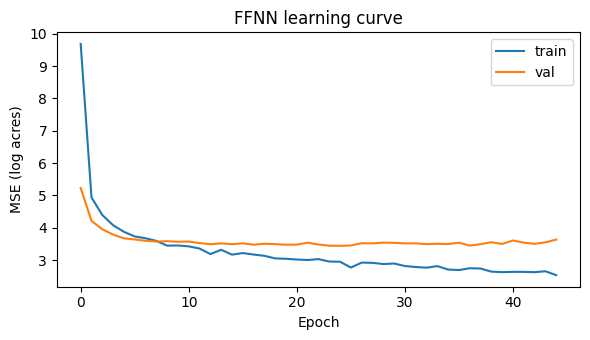

In [14]:
plt.figure(figsize=(6, 3.5))
plt.plot(hist_nn.history['loss'], label='train'); plt.plot(hist_nn.history['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE (log acres)'); plt.title('FFNN learning curve'); plt.legend(); plt.tight_layout(); plt.show()

In [15]:
param_dist = {
    'n_estimators':     [300, 500, 800],
    'learning_rate':    [0.01, 0.03, 0.05, 0.1],
    'max_depth':        [3, 4, 5, 6, 8],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.9],
    'min_child_weight': [1, 5, 10],
    'reg_lambda':       [1, 2, 5],
}
rs = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=SEED, tree_method='hist'),
    param_dist, n_iter=20, cv=3, scoring='neg_root_mean_squared_error',
    random_state=SEED, n_jobs=-1)
rs.fit(Xtr, ytr)
print('Best CV RMSE:', round(-rs.best_score_, 3)); print(rs.best_params_)

Best CV RMSE: 1.829
{'subsample': 0.6, 'reg_lambda': 5, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.9}


In [16]:
best = rs.best_params_.copy()
xgbm = xgb.XGBRegressor(**{**best, 'n_estimators': 2000}, random_state=SEED,
                        tree_method='hist', early_stopping_rounds=75)
xgbm.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
evaluate('XGBoost', (ytr, yva, yte),
         (xgbm.predict(Xtr), xgbm.predict(Xva), xgbm.predict(Xte)))

,Train RMSE,Train MAE,Train R2,Val RMSE,Val MAE,Val R2,Test RMSE,Test MAE,Test R2
XGBoost,1.493,1.148,0.447,1.77,1.4,0.16,1.943,1.453,0.145


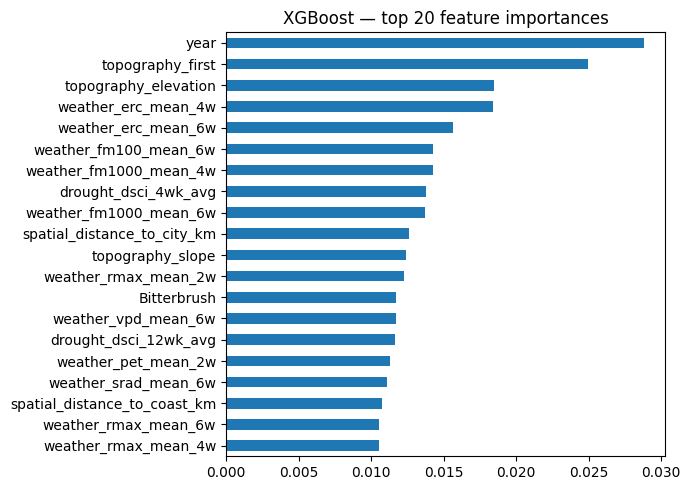

In [17]:
imps = pd.Series(xgbm.feature_importances_, index=FEATS).sort_values(ascending=False).head(20)
plt.figure(figsize=(7, 5)); imps[::-1].plot.barh()
plt.title('XGBoost — top 20 feature importances'); plt.tight_layout(); plt.show()

In [18]:
rf = RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_leaf=5,
                           max_features='sqrt', n_jobs=-1, random_state=SEED)
rf.fit(Xtr, ytr)
evaluate('Random Forest', (ytr, yva, yte), (rf.predict(Xtr), rf.predict(Xva), rf.predict(Xte)))

,Train RMSE,Train MAE,Train R2,Val RMSE,Val MAE,Val R2,Test RMSE,Test MAE,Test R2
Random Forest,1.175,0.876,0.658,1.78,1.409,0.151,1.954,1.469,0.135


In [19]:
summary = pd.DataFrame(results).T.round(3)
summary

,Train RMSE,Train MAE,Train R2,Val RMSE,Val MAE,Val R2,Test RMSE,Test MAE,Test R2
Baseline (mean),2.008,1.536,0.000,1.932,1.513,-0.000,2.102,1.578,-0.001
Linear Regression (TF),1.813,1.391,0.185,1.838,1.450,0.094,2.004,1.515,0.091
FFNN (TF),1.599,1.209,0.366,1.855,1.453,0.077,2.107,1.535,-0.005
XGBoost,1.493,1.148,0.447,1.770,1.400,0.160,1.943,1.453,0.145
Random Forest,1.175,0.876,0.658,1.780,1.409,0.151,1.954,1.469,0.135


In [20]:
n = len(df); i1, i2 = int(n*0.70), int(n*0.85)
tr_c, va_c, te_c = df.iloc[:i1], df.iloc[i1:i2], df.iloc[i2:]
print('Train through', tr_c['year'].max(), '| Test from', te_c['year'].min())
Xtr_c, Xva_c, Xte_c, _ = make_matrices(tr_c, va_c, te_c)
ytr_c, yva_c, yte_c = (d['log_acres'].values.astype('float32') for d in (tr_c, va_c, te_c))

chrono = {}
chrono['Baseline'] = np.sqrt(mean_squared_error(yte_c, np.full_like(yte_c, ytr_c.mean())))
m_c = xgb.XGBRegressor(**{**best, 'n_estimators': 2000}, random_state=SEED,
                       tree_method='hist', early_stopping_rounds=75)
m_c.fit(Xtr_c, ytr_c, eval_set=[(Xva_c, yva_c)], verbose=False)
chrono['XGBoost'] = np.sqrt(mean_squared_error(yte_c, m_c.predict(Xte_c)))
chrono['XGBoost R2'] = r2_score(yte_c, m_c.predict(Xte_c))
pd.Series(chrono).round(3)

Train through 2024 | Test from 2025


,0
Baseline,1.983
XGBoost,1.961
XGBoost R2,-0.414


In [21]:
te_eval = te.copy()
te_eval['pred'] = xgbm.predict(Xte)
te_eval['size_class'] = pd.cut(te_eval['fire_incident_acres_burned'],
                               [0, 100, 1000, 10000, np.inf],
                               labels=['<100 ac', '100–1k', '1k–10k', '>10k'])
te_eval['season'] = pd.cut(te_eval['month'], [0, 3, 6, 9, 12],
                           labels=['Winter', 'Spring', 'Summer', 'Fall'])
NORCAL = {'Shasta','Butte','Siskiyou','Trinity','Tehama','Plumas','Lassen','Modoc','Humboldt','Mendocino','Lake','Glenn','Colusa','Del Norte'}
te_eval['region'] = np.where(te_eval['fire_incident_county'].isin(NORCAL), 'Northern CA', 'Central/Southern CA')

def subgroup_table(col):
    g = te_eval.groupby(col, observed=True).apply(
        lambda d: pd.Series({'n': len(d),
                             'RMSE': np.sqrt(mean_squared_error(d['log_acres'], d['pred'])),
                             'MAE': mean_absolute_error(d['log_acres'], d['pred'])}))
    return g.round(3)

for col in ['size_class', 'season', 'region']:
    print(f'\n--- By {col} ---'); print(subgroup_table(col))


--- By size_class ---
                n   RMSE    MAE
size_class                     
<100 ac     312.0  1.367  1.126
100–1k      129.0  1.169  0.965
1k–10k       46.0  3.011  2.895
>10k         25.0  5.497  5.387

--- By season ---
            n   RMSE    MAE
season                     
Winter   18.0  1.637  1.326
Spring  158.0  1.598  1.202
Summer  285.0  2.103  1.576
Fall     51.0  2.079  1.583

--- By region ---
                         n   RMSE    MAE
region                                  
Central/Southern CA  386.0  1.896  1.393
Northern CA          126.0  2.080  1.634


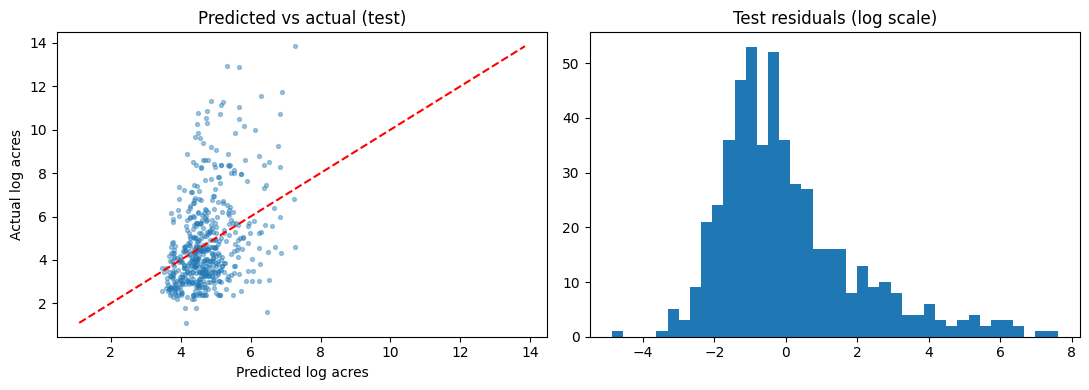

Median |residual| = 1.13 log units ≈ typical prediction within a factor of 3.1× of actual acreage


In [22]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(te_eval['pred'], te_eval['log_acres'], s=8, alpha=0.4)
lims = [te_eval['log_acres'].min(), te_eval['log_acres'].max()]
ax[0].plot(lims, lims, 'r--'); ax[0].set_xlabel('Predicted log acres'); ax[0].set_ylabel('Actual log acres')
ax[0].set_title('Predicted vs actual (test)')
resid = te_eval['log_acres'] - te_eval['pred']
ax[1].hist(resid, bins=40); ax[1].set_title('Test residuals (log scale)')
plt.tight_layout(); plt.show()

print(f'Median |residual| = {np.median(np.abs(resid)):.2f} log units '
      f'≈ typical prediction within a factor of {np.exp(np.median(np.abs(resid))):.1f}× of actual acreage')

In [23]:
from sklearn.model_selection import KFold

WEATHER_VARS = sorted({c[len('weather_'):].rsplit('_', 2)[0]
                       for c in df.columns if c.startswith('weather_') and c.endswith('_8w')})

def engineer(d):
    d = d.copy()

    for v in WEATHER_VARS:
        c2, c8 = f'weather_{v}_2w', f'weather_{v}_8w'
        if c2 in d.columns and c8 in d.columns:
            d[f'trend_{v}'] = d[c2] - d[c8]

    d['ix_erc_slope']    = d['weather_erc_mean_2w']    * d['topography_slope']
    d['ix_fm1000_wind']  = d['weather_fm1000_mean_2w'] * d['weather_vs_mean_2w']
    d['ix_vpd_slope']    = d['weather_vpd_mean_2w']    * d['topography_slope']
    d['ix_drought_elev'] = d['drought_dsci_current']   * d['topography_elevation']
    return d

df_e = engineer(df)
tr_e, va_e, te_e = df_e.loc[tr.index], df_e.loc[va.index], df_e.loc[te.index]

global_mean = tr_e['log_acres'].mean()
tr_e['county_te'] = global_mean
for tr_idx, ho_idx in KFold(5, shuffle=True, random_state=SEED).split(tr_e):
    fold_means = tr_e.iloc[tr_idx].groupby('fire_incident_county')['log_acres'].mean()
    tr_e.iloc[ho_idx, tr_e.columns.get_loc('county_te')] = \
        tr_e.iloc[ho_idx]['fire_incident_county'].map(fold_means).fillna(global_mean).values
full_means = tr_e.groupby('fire_incident_county')['log_acres'].mean()
for d in (va_e, te_e):
    d['county_te'] = d['fire_incident_county'].map(full_means).fillna(global_mean)

REDUNDANT = [c for c in NUM_COLS if c.startswith('weather_') and c.endswith(('_4w', '_6w', '_8w'))]
NEW = [c for c in tr_e.columns if c.startswith(('trend_', 'ix_'))] + ['county_te']
NUM_E = [c for c in NUM_COLS if c not in REDUNDANT] + NEW
print(f'Features: {len(NUM_COLS)} -> {len(NUM_E)} '
      f'(dropped {len(REDUNDANT)} redundant windows, added {len(NEW)} engineered)')

imp_e = SimpleImputer(strategy='median').fit(tr_e[NUM_E])
sc_e  = StandardScaler().fit(imp_e.transform(tr_e[NUM_E]))
cats_e = sorted(tr_e[CAT_COL].fillna('Unknown').unique().tolist())
def Xe(d):
    s = d[CAT_COL].fillna('Unknown')
    oh = np.stack([(s == c).astype(float).values for c in cats_e], axis=1)
    return np.hstack([sc_e.transform(imp_e.transform(d[NUM_E])), oh]).astype('float32')
Xtr_e, Xva_e, Xte_e = Xe(tr_e), Xe(va_e), Xe(te_e)

Features: 104 -> 58 (dropped 51 redundant windows, added 5 engineered)


In [24]:
xgb_e = xgb.XGBRegressor(
    n_estimators=2000, learning_rate=0.02, max_depth=5, subsample=0.8,
    colsample_bytree=0.7, min_child_weight=5, reg_lambda=3,
    random_state=SEED, tree_method='hist', early_stopping_rounds=100)
xgb_e.fit(Xtr_e, ytr, eval_set=[(Xva_e, yva)], verbose=False)
display(evaluate('XGB engineered', (ytr, yva, yte),
        (xgb_e.predict(Xtr_e), xgb_e.predict(Xva_e), xgb_e.predict(Xte_e))))

imps_e = pd.Series(xgb_e.feature_importances_,
                   index=NUM_E + cats_e).sort_values(ascending=False).head(15)
imps_e.round(3)

,Train RMSE,Train MAE,Train R2,Val RMSE,Val MAE,Val R2,Test RMSE,Test MAE,Test R2
XGB engineered,1.486,1.154,0.452,1.77,1.382,0.16,1.85,1.396,0.225


,0
year,0.050
county_te,0.042
ix_erc_slope,0.040
topography_first,0.033
ix_drought_elev,0.026
topography_elevation,0.025
weather_fm1000_mean_2w,0.024
weather_erc_mean_2w,0.021
ix_vpd_slope,0.019
spatial_distance_to_city_km,0.018


In [25]:
xgb_q = xgb.XGBRegressor(
    objective='reg:quantileerror', quantile_alpha=0.9,
    n_estimators=1500, learning_rate=0.03, max_depth=4, subsample=0.8,
    colsample_bytree=0.7, min_child_weight=5, reg_lambda=3,
    random_state=SEED, tree_method='hist', early_stopping_rounds=100)
xgb_q.fit(Xtr_e, ytr, eval_set=[(Xva_e, yva)], verbose=False)
q90 = xgb_q.predict(Xte_e)
big = (te_e['fire_incident_acres_burned'] > 10000).values
print(f'Q90 coverage on test: {(yte <= q90).mean():.2%} (target ~90%)')
print(f'Q90 coverage on >10k-acre fires: {(yte[big] <= q90[big]).mean():.2%} (n={big.sum()})')

Q90 coverage on test: 87.30% (target ~90%)
Q90 coverage on >10k-acre fires: 0.00% (n=25)


In [26]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

BINS = [0, 100, 1000, 10000, np.inf]; LABELS = ['<100', '100-1k', '1k-10k', '>10k']
def to_class(d): return pd.cut(d['fire_incident_acres_burned'], BINS, labels=LABELS).cat.codes.values
ctr, cva, cte = to_class(tr_e), to_class(va_e), to_class(te_e)

clf = xgb.XGBClassifier(
    objective='multi:softprob', num_class=4, n_estimators=1500, learning_rate=0.03,
    max_depth=4, subsample=0.8, colsample_bytree=0.7, min_child_weight=5,
    reg_lambda=3, random_state=SEED, tree_method='hist', early_stopping_rounds=100)
w = pd.Series(ctr).map(pd.Series(ctr).value_counts().max() / pd.Series(ctr).value_counts()).values
clf.fit(Xtr_e, ctr, sample_weight=w, eval_set=[(Xva_e, cva)], verbose=False)
pte = clf.predict(Xte_e)
print(f'Accuracy: {accuracy_score(cte, pte):.3f} | macro-F1: {f1_score(cte, pte, average="macro"):.3f}')
print(f'Within-one-class accuracy: {(np.abs(cte - pte) <= 1).mean():.3f}')
print(classification_report(cte, pte, target_names=LABELS, digits=3))

Accuracy: 0.555 | macro-F1: 0.389
Within-one-class accuracy: 0.873
              precision    recall  f1-score   support

        <100      0.726     0.696     0.710       312
      100-1k      0.346     0.411     0.376       129
      1k-10k      0.171     0.130     0.148        46
        >10k      0.320     0.320     0.320        25

    accuracy                          0.555       512
   macro avg      0.391     0.389     0.389       512
weighted avg      0.561     0.555     0.556       512



In [27]:
for d in (tr_e, va_e, te_e):
    d['veg_missing'] = d[CAT_COL].isna().astype(float)

print('Mean log_acres | veg present:', round(tr_e.loc[tr_e.veg_missing==0,'log_acres'].mean(),3),
      '| veg missing:', round(tr_e.loc[tr_e.veg_missing==1,'log_acres'].mean(),3))

NUM_E2 = NUM_E + ['veg_missing']
imp_e = SimpleImputer(strategy='median').fit(tr_e[NUM_E2])
sc_e  = StandardScaler().fit(imp_e.transform(tr_e[NUM_E2]))
def Xe(d):
    s = d[CAT_COL].fillna('Unknown')
    oh = np.stack([(s == c).astype(float).values for c in cats_e], axis=1)
    return np.hstack([sc_e.transform(imp_e.transform(d[NUM_E2])), oh]).astype('float32')
Xtr_e, Xva_e, Xte_e = Xe(tr_e), Xe(va_e), Xe(te_e)

xgb_m = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.02, max_depth=5, subsample=0.8,
    colsample_bytree=0.7, min_child_weight=5, reg_lambda=3, random_state=SEED,
    tree_method='hist', early_stopping_rounds=100)
xgb_m.fit(Xtr_e, ytr, eval_set=[(Xva_e, yva)], verbose=False)
print('With veg_missing -> val R2:', round(r2_score(yva, xgb_m.predict(Xva_e)),3),
      '| test R2:', round(r2_score(yte, xgb_m.predict(Xte_e)),3))

Mean log_acres | veg present: 4.632 | veg missing: 5.024
With veg_missing -> val R2: 0.164 | test R2: 0.222


In [28]:
from sklearn.metrics import accuracy_score, f1_score

BINS = [0, 100, 1000, 10000, np.inf]; LABELS = ['<100', '100-1k', '1k-10k', '>10k']
def to_class(d): return pd.cut(d['fire_incident_acres_burned'], BINS, labels=LABELS).cat.codes.values
ctr, cva, cte = to_class(tr_e), to_class(va_e), to_class(te_e)

clf_results = {}
def score_clf(name, y_true, y_pred):
    y_true = np.asarray(y_true).astype(int); y_pred = np.asarray(y_pred).astype(int)
    mega = (y_true == 3)
    clf_results[name] = {
        'Accuracy':        accuracy_score(y_true, y_pred),
        'Macro-F1':        f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Within-1 bucket': (np.abs(y_true - y_pred) <= 1).mean(),
        'Megafire recall': (y_pred[mega] == 3).mean() if mega.sum() else np.nan,
    }
    return pd.DataFrame({name: clf_results[name]}).T.round(3)

majority = np.bincount(np.asarray(ctr).astype(int), minlength=4).argmax()
display(score_clf('Majority-class baseline', cte, np.full(len(cte), majority)))

tf.random.set_seed(SEED)
logreg = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(Xtr_e.shape[1],)),
    tf.keras.layers.Dense(4, activation='softmax')
])
logreg.compile(optimizer=tf.keras.optimizers.Adam(1e-2),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])
logreg.fit(Xtr_e, ctr, validation_data=(Xva_e, cva), epochs=300, batch_size=64, verbose=0,
           callbacks=[tf.keras.callbacks.EarlyStopping(patience=25, restore_best_weights=True,
                                                       monitor='val_loss')])
c_lr = logreg.predict(Xte_e, verbose=0).argmax(axis=1)
score_clf('Logistic Regression (TF)', cte, c_lr)

,Accuracy,Macro-F1,Within-1 bucket,Megafire recall
Majority-class baseline,0.609,0.189,0.861,0.0


,Accuracy,Macro-F1,Within-1 bucket,Megafire recall
Logistic Regression (TF),0.596,0.329,0.877,0.12


In [29]:
from sklearn.metrics import precision_score, recall_score

BINS = [0, 100, 1000, 10000, np.inf]; LABELS = ['<100', '100-1k', '1k-10k', '>10k']
def to_class(d): return pd.cut(d['fire_incident_acres_burned'], BINS, labels=LABELS).cat.codes.values
ctr, cva, cte = to_class(tr_e), to_class(va_e), to_class(te_e)

clf = xgb.XGBClassifier(
    objective='multi:softprob', num_class=4, n_estimators=1500, learning_rate=0.03,
    max_depth=4, subsample=0.8, colsample_bytree=0.7, min_child_weight=5,
    reg_lambda=3, random_state=SEED, tree_method='hist', early_stopping_rounds=100)
w = pd.Series(ctr).map(pd.Series(ctr).value_counts().max() / pd.Series(ctr).value_counts()).values
clf.fit(Xtr_e, ctr, sample_weight=w, eval_set=[(Xva_e, cva)], verbose=False)

proba_va, proba_te = clf.predict_proba(Xva_e), clf.predict_proba(Xte_e)
p_large_va = proba_va[:, 2:].sum(axis=1)
p_large_te = proba_te[:, 2:].sum(axis=1)
y_large_va, y_large_te = (cva >= 2).astype(int), (cte >= 2).astype(int)

rows = []
for t in np.arange(0.05, 0.65, 0.05):
    pred = (p_large_va >= t).astype(int)
    rows.append({'thresh': round(t, 2),
                 'recall': recall_score(y_large_va, pred),
                 'precision': precision_score(y_large_va, pred, zero_division=0),
                 'flagged_%': pred.mean() * 100})
sweep = pd.DataFrame(rows)
print(sweep.round(3).to_string(index=False))

ok = sweep[sweep.recall >= 0.75]
t_star = ok.iloc[-1]['thresh'] if len(ok) else 0.5
print(f'\nSelected threshold (val recall >= 0.75): {t_star}')

pred_te = (p_large_te >= t_star).astype(int)
print(f'TEST large-fire (>1k ac, n={y_large_te.sum()}): '
      f'recall={recall_score(y_large_te, pred_te):.3f}  '
      f'precision={precision_score(y_large_te, pred_te):.3f}  '
      f'flagged={pred_te.mean()*100:.1f}% of fires')
mega = (cte == 3)
argmax_recall = (proba_te.argmax(axis=1)[mega] == 3).mean()
print(f'TEST megafires (>10k ac, n={mega.sum()}): '
      f'recall={pred_te[mega].mean():.3f} (vs {argmax_recall:.3f} at argmax)')

 thresh  recall  precision  flagged_%
   0.05   0.957      0.163     79.102
   0.10   0.870      0.196     59.766
   0.15   0.783      0.220     47.852
   0.20   0.681      0.242     37.891
   0.25   0.594      0.265     30.273
   0.30   0.478      0.266     24.219
   0.35   0.435      0.288     20.312
   0.40   0.362      0.309     15.820
   0.45   0.290      0.312     12.500
   0.50   0.203      0.318      8.594
   0.55   0.203      0.389      7.031
   0.60   0.188      0.419      6.055

Selected threshold (val recall >= 0.75): 0.15
TEST large-fire (>1k ac, n=71): recall=0.648  precision=0.188  flagged=47.9% of fires
TEST megafires (>10k ac, n=25): recall=0.680 (vs 0.360 at argmax)


In [30]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

counts = pd.Series(ctr).value_counts()
w_sqrt = pd.Series(ctr).map(np.sqrt(counts.max() / counts)).values

clf = xgb.XGBClassifier(
    objective='multi:softprob', num_class=4, n_estimators=1500, learning_rate=0.03,
    max_depth=4, subsample=0.8, colsample_bytree=0.7, min_child_weight=5,
    reg_lambda=3, random_state=SEED, tree_method='hist', early_stopping_rounds=100)
clf.fit(Xtr_e, ctr, sample_weight=w_sqrt, eval_set=[(Xva_e, cva)], verbose=False)

pte = clf.predict(Xte_e)
print(f'Majority-class baseline: {(cte == 0).mean():.3f}')
print(f'Accuracy: {accuracy_score(cte, pte):.3f} | macro-F1: {f1_score(cte, pte, average="macro"):.3f}')
print(f'Within-one-bucket: {(np.abs(cte - pte) <= 1).mean():.3f}')
print(classification_report(cte, pte, target_names=LABELS, digits=3))

Majority-class baseline: 0.609
Accuracy: 0.611 | macro-F1: 0.405
Within-one-bucket: 0.885
              precision    recall  f1-score   support

        <100      0.719     0.821     0.766       312
      100-1k      0.389     0.341     0.364       129
      1k-10k      0.211     0.087     0.123        46
        >10k      0.375     0.360     0.367        25

    accuracy                          0.611       512
   macro avg      0.424     0.402     0.405       512
weighted avg      0.574     0.611     0.588       512



In [31]:
score_clf('XGBoost classifier (sqrt weights)', cte, pte)
pd.DataFrame(clf_results).T.round(3)

,Accuracy,Macro-F1,Within-1 bucket,Megafire recall
Majority-class baseline,0.609,0.189,0.861,0.00
Logistic Regression (TF),0.596,0.329,0.877,0.12
XGBoost classifier (sqrt weights),0.611,0.405,0.885,0.36
